In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [2]:
env = gym.make("FrozenLake-v1", is_slippery=False)

n_states = env.observation_space.n
n_actions = env.action_space.n

In [3]:
num_episodes = 20000
gamma = 0.99
alpha = 0.1

epsilon_start = 1.0
epsilon_min = 0.05
epsilon_decay = 0.9995

max_steps_per_episode = 100

In [4]:
Q = np.zeros((n_states, n_actions))
episode_rewards = []


def epsilon_greedy_action(state, epsilon):
    if np.random.random() < epsilon:
        return np.random.randint(n_actions)
    else:
        return np.argmax(Q[state])

In [5]:
def generate_episode(epsilon):


    episode = []

    state, info = env.reset()

    for _ in range(max_steps_per_episode):
        action = epsilon_greedy_action(state, epsilon)

        next_state, reward, terminated, truncated, info = env.step(action)

        episode.append((state, action, reward))

        state = next_state

        if terminated or truncated:
            break

    return episode

In [6]:
epsilon = epsilon_start

for episode_num in range(num_episodes):

    episode = generate_episode(epsilon)

    G = 0

    # Track which state-action pairs have already been updated
    visited = set()

    for state, action, reward in reversed(episode):

        G = gamma * G + reward

        if (state, action) not in visited:
            Q[state, action] += alpha * (
                G - Q[state, action]
            )

            visited.add((state, action))

    episode_rewards.append(sum(
        reward for _, _, reward in episode
    ))

    # Decay epsilon
    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )

In [7]:
optimal_policy = np.argmax(Q, axis=1)
state_values = np.max(Q, axis=1)

In [8]:
def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)
    print("Name:Sunil Kumar T")
    print("Register Number:212223240164")
    print("\nLearned Policy:")
    print(policy_grid)


def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(optimal_policy)

success_rate = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", success_rate)


Final Q-table:
[[0.746 0.802 0.94  0.687]
 [0.513 0.    0.951 0.533]
 [0.614 0.961 0.571 0.65 ]
 [0.63  0.    0.233 0.315]
 [0.698 0.81  0.    0.64 ]
 [0.    0.    0.    0.   ]
 [0.    0.972 0.    0.704]
 [0.    0.    0.    0.   ]
 [0.809 0.    0.822 0.782]
 [0.922 0.882 0.98  0.   ]
 [0.947 0.99  0.    0.934]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.959 0.99  0.96 ]
 [0.98  0.99  1.    0.975]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.94  0.951 0.961 0.63 ]
 [0.81  0.    0.972 0.   ]
 [0.822 0.98  0.99  0.   ]
 [0.    0.99  1.    0.   ]]
Name:Sunil Kumar T
Register Number:212223240164

Learned Policy:
[['R' 'R' 'D' 'L']
 ['D' 'L' 'D' 'L']
 ['R' 'R' 'D' 'L']
 ['L' 'R' 'R' 'L']]

Average reward over last 1000 episodes: 0.934


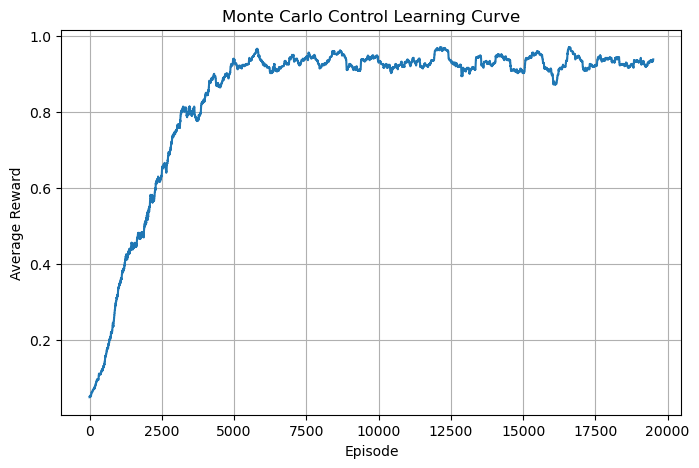

In [9]:
window = 500
moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Monte Carlo Control Learning Curve")
plt.grid(True)
plt.show()

env.close()